# Phân tích dữ liệu Netflix

Notebook khám phá bộ dữ liệu `netflix_titles-clean.csv` bằng **pandas**, **Matplotlib** và **Seaborn**.

Nội dung gồm: kiểm tra chất lượng dữ liệu, cơ cấu Movie/TV Show, xu hướng phát hành, quốc gia, thể loại, rating, thời lượng và thời điểm nội dung được thêm lên Netflix.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
NETFLIX_RED = '#E50914'
COLORS = [NETFLIX_RED, '#221F1F', '#B81D24', '#F5F5F1', '#6D6D6D']
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

## 1. Đọc và chuẩn hóa dữ liệu

In [2]:
DATA_CANDIDATES = [Path('netflix_titles_clean.csv'), Path('netflix_titles-clean.csv')]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Không tìm thấy netflix_titles_clean.csv trong thư mục hiện tại')

df = pd.read_csv(DATA_PATH)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('Int64')
df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month
df['duration_value'] = pd.to_numeric(df['duration'].str.extract(r'(\d+)')[0], errors='coerce')

print(f'Số dòng: {len(df):,} | Số cột gốc: 12 | Số cột sau xử lý: {df.shape[1]}')
display(df.head())

Số dòng: 8,807 | Số cột gốc: 12 | Số cột sau xử lý: 15


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages hi...",2021,9.0,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Na...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether ...",2021,9.0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Sal...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his...",2021,9.0,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at t...",2021,9.0,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pi...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies",In a city of coaching centers known to train India’s finest collegiate minds...,2021,9.0,2.0


## 2. Tổng quan và chất lượng dữ liệu

In [3]:
summary = pd.DataFrame({
    'Kiểu dữ liệu': df.dtypes.astype(str),
    'Số giá trị thiếu': df.isna().sum(),
    'Tỷ lệ thiếu (%)': (df.isna().mean() * 100).round(2),
    'Số giá trị duy nhất': df.nunique(dropna=True)
})
display(summary)
print(f'Số dòng trùng hoàn toàn: {df.duplicated().sum():,}')
print(f'Số show_id trùng: {df["show_id"].duplicated().sum():,}')

,Kiểu dữ liệu,Số giá trị thiếu,Tỷ lệ thiếu (%),Số giá trị duy nhất
show_id,str,0,0.00,8807
type,str,0,0.00,2
title,str,0,0.00,8807
director,str,0,0.00,4529
cast,str,0,0.00,7693
country,str,0,0.00,749
date_added,datetime64[us],10,0.11,1714
release_year,Int64,0,0.00,74
rating,str,0,0.00,18
duration,str,0,0.00,221


Số dòng trùng hoàn toàn: 0
Số show_id trùng: 0


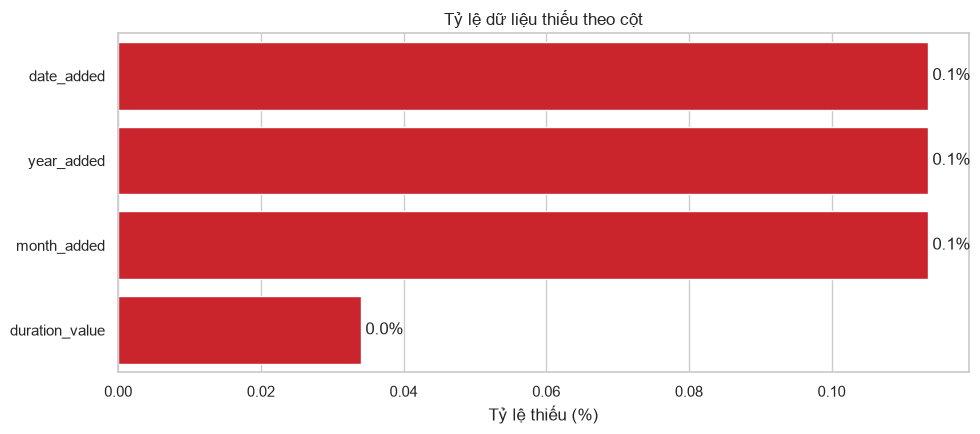

In [4]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('Không có giá trị thiếu theo chuẩn NaN.')
else:
    plt.figure(figsize=(10, 4.5))
    ax = sns.barplot(x=missing.values, y=missing.index, color=NETFLIX_RED)
    ax.set(title='Tỷ lệ dữ liệu thiếu theo cột', xlabel='Tỷ lệ thiếu (%)', ylabel='')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)
    plt.tight_layout()
    plt.show()

## 3. Cơ cấu Movie và TV Show

,Số lượng,Tỷ trọng (%)
type,,
Movie,6131,69.6
TV Show,2676,30.4


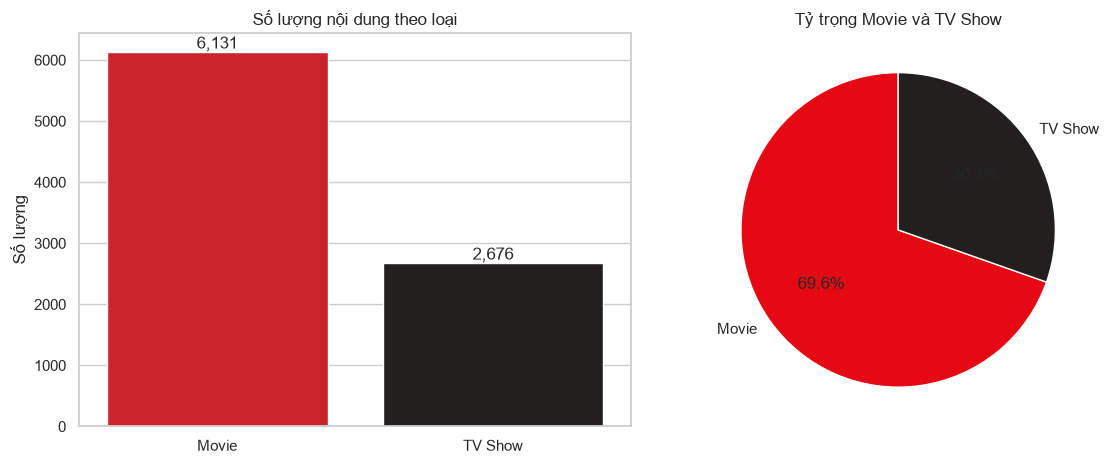

In [5]:
type_counts = df['type'].value_counts()
type_pct = (df['type'].value_counts(normalize=True) * 100).round(1)
display(pd.DataFrame({'Số lượng': type_counts, 'Tỷ trọng (%)': type_pct}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.barplot(x=type_counts.index, y=type_counts.values, palette=COLORS[:2], ax=axes[0])
axes[0].set(title='Số lượng nội dung theo loại', xlabel='', ylabel='Số lượng')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:,.0f}')
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            startangle=90, colors=COLORS[:2], wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Tỷ trọng Movie và TV Show')
plt.tight_layout()
plt.show()

## 4. Xu hướng nội dung theo năm phát hành

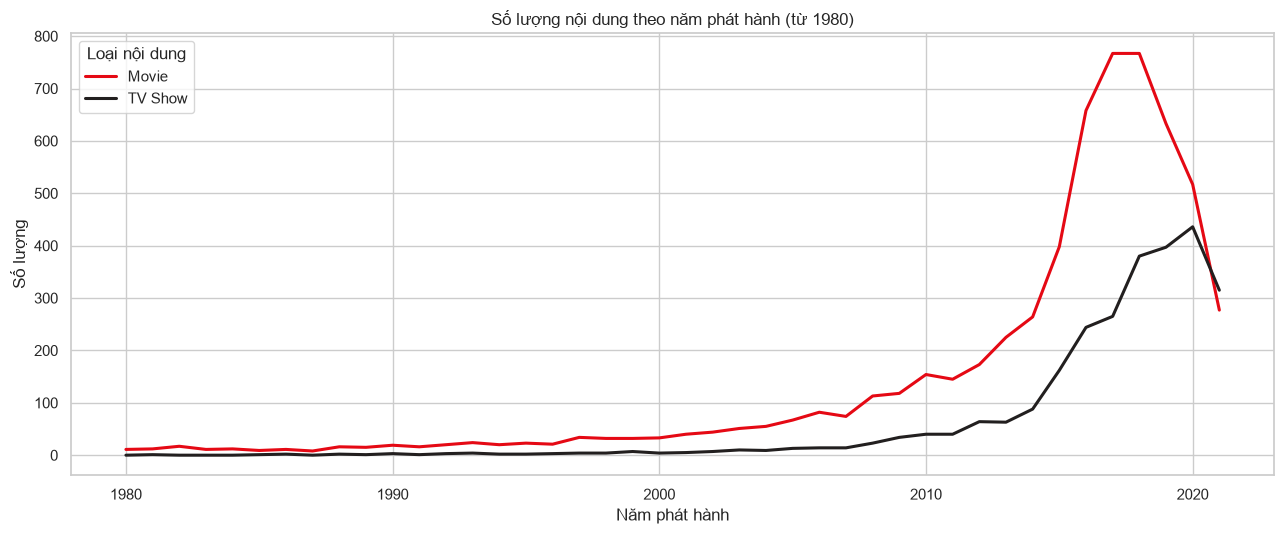

In [6]:
yearly = (df.dropna(subset=['release_year'])
          .groupby(['release_year', 'type']).size()
          .unstack(fill_value=0).sort_index())
recent_yearly = yearly.loc[yearly.index >= 1980]

ax = recent_yearly.plot(figsize=(13, 5.5), color=[NETFLIX_RED, '#221F1F'], linewidth=2.2)
ax.set(title='Số lượng nội dung theo năm phát hành (từ 1980)',
       xlabel='Năm phát hành', ylabel='Số lượng')
ax.legend(title='Loại nội dung')
plt.tight_layout()
plt.show()

## 5. Quốc gia sản xuất nổi bật
Một tác phẩm có thể gắn với nhiều quốc gia, vì vậy cần tách cột `country` trước khi đếm.

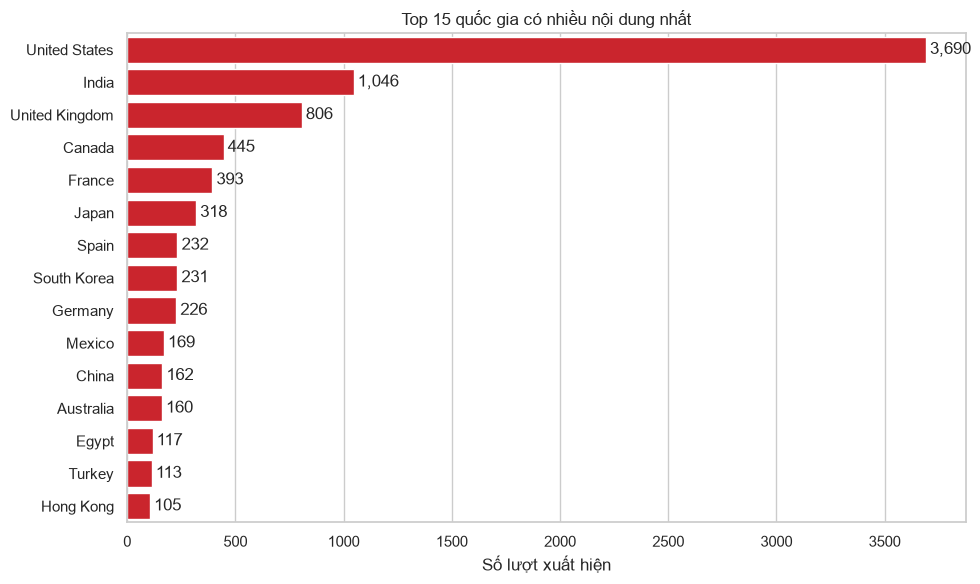

In [7]:
countries = (df.assign(country=df['country'].fillna('Unknown').str.split(','))
             .explode('country'))
countries['country'] = countries['country'].str.strip()
top_countries = countries.loc[countries['country'].ne('Unknown'), 'country'].value_counts().head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_countries.values, y=top_countries.index, color=NETFLIX_RED)
ax.set(title='Top 15 quốc gia có nhiều nội dung nhất', xlabel='Số lượt xuất hiện', ylabel='')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)
plt.tight_layout()
plt.show()

## 6. Thể loại phổ biến
Tương tự quốc gia, mỗi nội dung có thể thuộc nhiều thể loại.

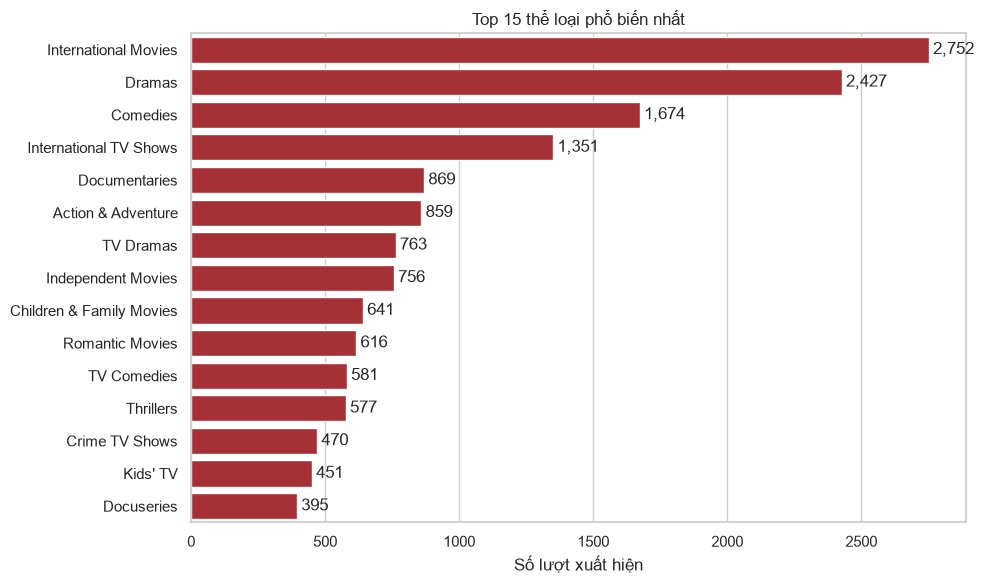

In [8]:
genres = df.assign(genre=df['listed_in'].str.split(',')).explode('genre')
genres['genre'] = genres['genre'].str.strip()
top_genres = genres['genre'].value_counts().head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_genres.values, y=top_genres.index, color='#B81D24')
ax.set(title='Top 15 thể loại phổ biến nhất', xlabel='Số lượt xuất hiện', ylabel='')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)
plt.tight_layout()
plt.show()

## 7. Phân bố xếp hạng độ tuổi

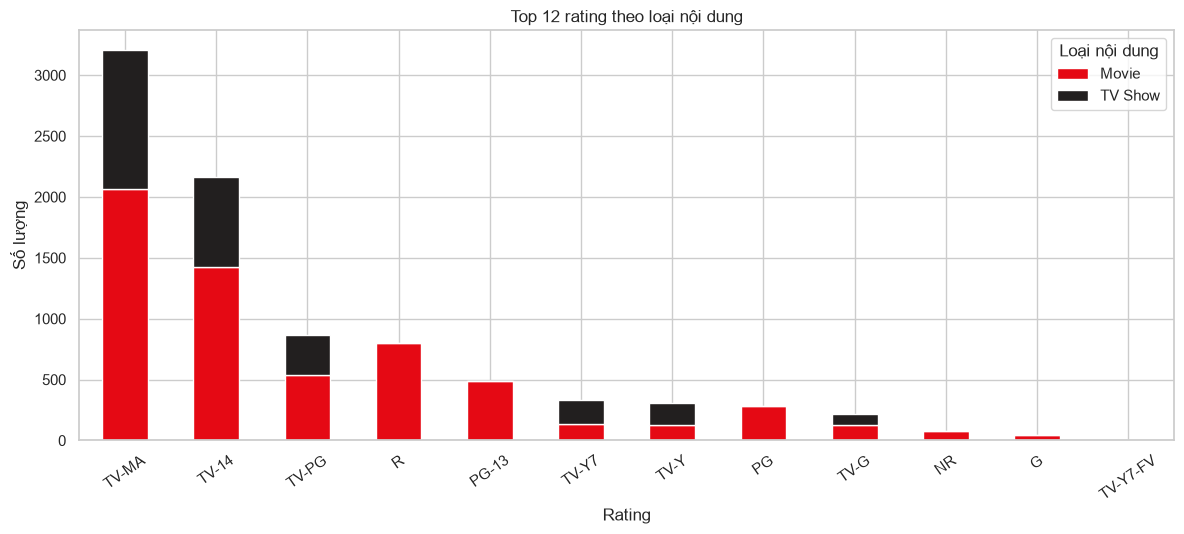

In [9]:
rating_by_type = pd.crosstab(df['rating'], df['type'])
rating_by_type['Tổng'] = rating_by_type.sum(axis=1)
rating_by_type = rating_by_type.sort_values('Tổng', ascending=False).head(12).drop(columns='Tổng')

ax = rating_by_type.plot(kind='bar', stacked=True, figsize=(12, 5.5),
                         color=[NETFLIX_RED, '#221F1F'])
ax.set(title='Top 12 rating theo loại nội dung', xlabel='Rating', ylabel='Số lượng')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Loại nội dung')
plt.tight_layout()
plt.show()

## 8. Phân tích thời lượng
Movie được đo bằng phút; TV Show được đo bằng số season.

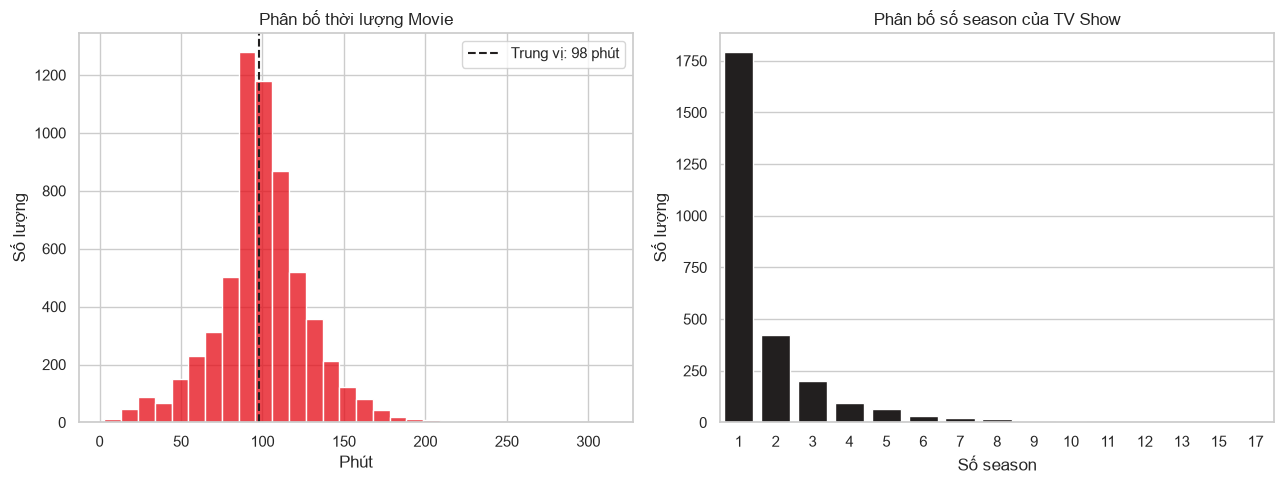

In [10]:
movies = df[df['type'].eq('Movie')].dropna(subset=['duration_value'])
shows = df[df['type'].eq('TV Show')].dropna(subset=['duration_value'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(movies['duration_value'], bins=30, color=NETFLIX_RED, ax=axes[0])
axes[0].axvline(movies['duration_value'].median(), color='#221F1F', linestyle='--',
                label=f"Trung vị: {movies['duration_value'].median():.0f} phút")
axes[0].set(title='Phân bố thời lượng Movie', xlabel='Phút', ylabel='Số lượng')
axes[0].legend()

season_counts = shows['duration_value'].value_counts().sort_index().head(15)
sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, color='#221F1F', ax=axes[1])
axes[1].set(title='Phân bố số season của TV Show', xlabel='Số season', ylabel='Số lượng')
plt.tight_layout()
plt.show()

## 9. Nội dung được thêm lên Netflix theo thời gian

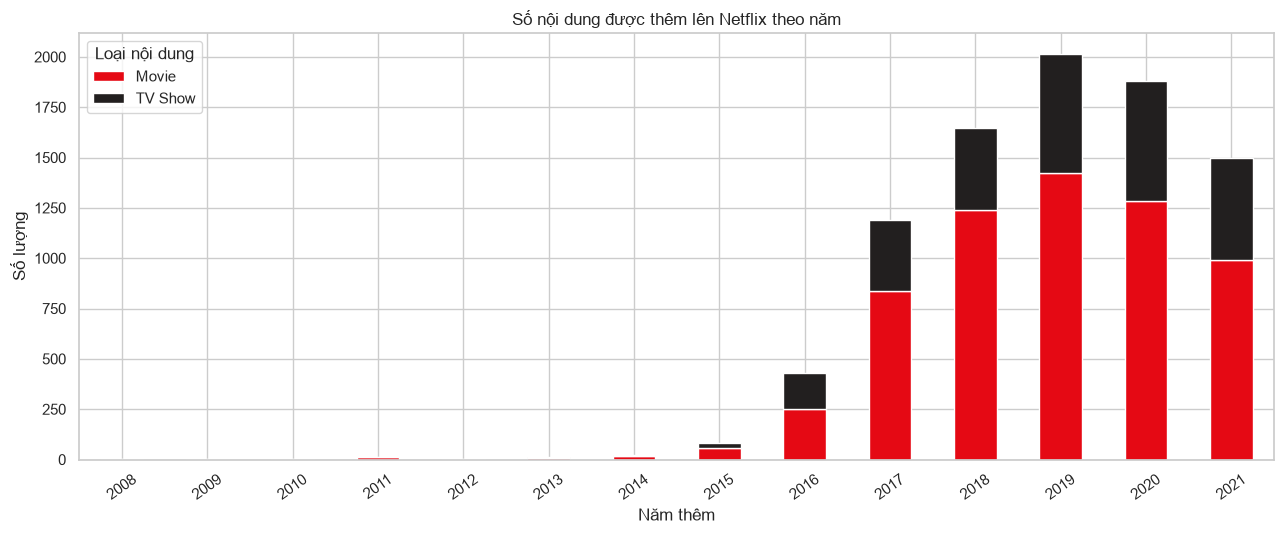

In [11]:
added = (df.dropna(subset=['year_added'])
         .groupby(['year_added', 'type']).size()
         .unstack(fill_value=0).sort_index())

ax = added.plot(kind='bar', stacked=True, figsize=(13, 5.5), color=[NETFLIX_RED, '#221F1F'])
ax.set(title='Số nội dung được thêm lên Netflix theo năm', xlabel='Năm thêm', ylabel='Số lượng')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Loại nội dung')
plt.tight_layout()
plt.show()

## 10. Khoảng cách từ năm phát hành đến năm được thêm

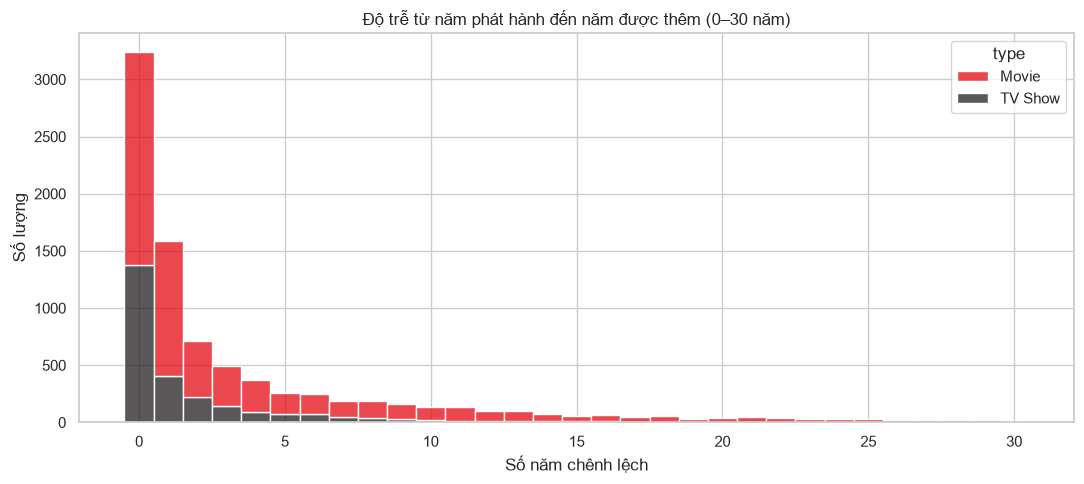

In [12]:
lag_df = df.dropna(subset=['year_added', 'release_year']).copy()
lag_df['release_to_add_lag'] = lag_df['year_added'].astype(int) - lag_df['release_year'].astype(int)
lag_df = lag_df[lag_df['release_to_add_lag'].between(0, 30)]

plt.figure(figsize=(11, 5))
sns.histplot(data=lag_df, x='release_to_add_lag', hue='type', multiple='stack',
             discrete=True, palette=[NETFLIX_RED, '#221F1F'])
plt.title('Độ trễ từ năm phát hành đến năm được thêm (0–30 năm)')
plt.xlabel('Số năm chênh lệch')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

## 11. Bảng tóm tắt insight tự động

In [13]:
top_country = top_countries.index[0]
top_genre = top_genres.index[0]
top_rating = df['rating'].value_counts().index[0]
peak_release_year = int(df['release_year'].value_counts().index[0])
peak_added_year = int(df['year_added'].value_counts().index[0])
movie_share = df['type'].eq('Movie').mean() * 100

insights = pd.DataFrame({
    'Chỉ số': [
        'Tổng số nội dung', 'Tỷ trọng Movie', 'Quốc gia nổi bật',
        'Thể loại phổ biến', 'Rating phổ biến',
        'Năm phát hành có nhiều nội dung nhất', 'Năm thêm nhiều nội dung nhất',
        'Thời lượng Movie trung vị'
    ],
    'Kết quả': [
        f'{len(df):,}', f'{movie_share:.1f}%', top_country, top_genre, top_rating,
        peak_release_year, peak_added_year, f"{movies['duration_value'].median():.0f} phút"
    ]
})
display(insights)

,Chỉ số,Kết quả
0,Tổng số nội dung,"8,807"
1,Tỷ trọng Movie,69.6%
2,Quốc gia nổi bật,United States
3,Thể loại phổ biến,International Movies
4,Rating phổ biến,TV-MA
5,Năm phát hành có nhiều nội dung nhất,2018
6,Năm thêm nhiều nội dung nhất,2019
7,Thời lượng Movie trung vị,98 phút


## Kết luận và gợi ý mở rộng

Các biểu đồ trên cho cái nhìn tổng quan về danh mục Netflix. Có thể mở rộng bằng cách:

- Phân tích đạo diễn và diễn viên xuất hiện nhiều nhất.
- So sánh thể loại theo từng quốc gia.
- Xây dựng word cloud từ phần mô tả.
- Tạo dashboard tương tác bằng Plotly.
- Xây dựng hệ thống gợi ý nội dung từ `description` và `listed_in`.